# 08 - Results, Analysis, and Figures

Turn notebook 07's immutable multi-seed result bundle into compact final tables,
figures, findings, and a report manifest. This notebook does not train models,
rescore predictions, or rebuild the MovieLens-1M protocol. Notebook 02 owns the
dataset/protocol; notebook 07 owns multi-seed aggregation; notebook 08 only
formats and exports report-ready evidence.

## Linkage and Cell Plan

**Upstream link:** read `evaluations/ml-1m/multiseed-v1/manifest.json` from
notebook 07, verify its immutable generation manifest and all declared CSV
artifacts, then use those tables as the only source of results.

**Cell work:**
1. Configure paths and helper functions, then verify/load notebook 07 outputs.
2. Build the main model comparison table and two phase figures for F1 and AUC.
3. Build a concise paired-delta table, ablation-selection table, and findings.
4. Export report CSVs, PNGs, findings markdown, and a report manifest.
5. Run final checks and state what notebook 09 should consume.

In [1]:
from __future__ import annotations

import hashlib
import importlib.util
import json
import os
import platform
import shutil
import uuid
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

REQUIRED_PACKAGES = ["numpy", "pandas", "matplotlib", "IPython"]
MISSING_PACKAGES = [
    package for package in REQUIRED_PACKAGES if importlib.util.find_spec(package) is None
]
if MISSING_PACKAGES:
    raise RuntimeError(
        "Notebook 08 requires these packages in the active kernel: "
        + ", ".join(MISSING_PACKAGES)
        + ". Run it in the project ML/Kaggle environment used for result notebooks."
    )

import matplotlib

matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def show_records(records: Iterable[dict[str, Any]]) -> None:
    display(pd.DataFrame(list(records)))


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def reject_json_constant(value: str) -> None:
    raise ValueError(f"Non-finite JSON constant is not allowed: {value}")


def strict_json_loads(payload: str | bytes) -> Any:
    return json.loads(payload, parse_constant=reject_json_constant)


def strict_json_dumps(value: Any, **kwargs: Any) -> str:
    return json.dumps(value, allow_nan=False, **kwargs)


def project_root(start: Path) -> Path:
    override = os.environ.get("COLDSTART_PROJECT_ROOT")
    if override:
        return Path(override).expanduser().resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate.resolve()
    return start.resolve()


def resolve_inside(root: Path, relative_path: str) -> Path:
    resolved_root = root.resolve()
    resolved = (resolved_root / relative_path).resolve()
    resolved.relative_to(resolved_root)
    return resolved


def load_json(path: Path) -> dict[str, Any]:
    value = strict_json_loads(path.read_text(encoding="utf-8"))
    if not isinstance(value, dict):
        raise ValueError(f"JSON document is not an object: {path}")
    return value


EXECUTION_CONTEXT = "kaggle" if Path("/kaggle/input").exists() else "local"
PROJECT_ROOT = project_root(Path.cwd())
WORKSPACE_ROOT = Path(
    os.environ.get(
        "COLDSTART_WORKSPACE_ROOT",
        "/kaggle/working" if EXECUTION_CONTEXT == "kaggle" else PROJECT_ROOT / ".notebook",
    )
).expanduser().resolve()
INPUT_ROOT = Path(
    os.environ.get(
        "COLDSTART_INPUT_ROOT",
        "/kaggle/input" if EXECUTION_CONTEXT == "kaggle" else PROJECT_ROOT / "data",
    )
).expanduser().resolve()
ARTIFACT_ROOT = Path(
    os.environ.get("COLDSTART_ARTIFACT_ROOT", WORKSPACE_ROOT / "artifacts")
).expanduser().resolve()
MULTISEED_RELATIVE_MANIFEST = Path("evaluations/ml-1m/multiseed-v1/manifest.json")
OUTPUT_ROOT = ARTIFACT_ROOT / "reports" / "ml-1m" / "results-v1"
PHASE_DEFAULT = ["Cold", "Warm A", "Warm B", "Warm C"]


def multiseed_candidates() -> list[tuple[Path, Path]]:
    candidates: list[tuple[Path, Path]] = []
    explicit = os.environ.get("COLDSTART_MULTISEED_ROOT")
    roots = [Path(explicit).expanduser()] if explicit else []
    roots.extend([PROJECT_ROOT / ".notebook" / "artifacts", ARTIFACT_ROOT])

    for root in roots:
        pointer = root / MULTISEED_RELATIVE_MANIFEST
        if pointer.is_file():
            candidates.append((root.resolve(), pointer.resolve()))
        direct = root / "manifest.json"
        if root.name == "multiseed-v1" and direct.is_file():
            candidates.append((root.parents[2].resolve(), direct.resolve()))

    if INPUT_ROOT.is_dir():
        for pointer in sorted(INPUT_ROOT.rglob("manifest.json")):
            parent = pointer.parent
            if (
                parent.name == "multiseed-v1"
                and parent.parent.name == "ml-1m"
                and parent.parent.parent.name == "evaluations"
            ):
                candidates.append((pointer.parents[3].resolve(), pointer.resolve()))

    unique: list[tuple[Path, Path]] = []
    seen: set[str] = set()
    for root, pointer in candidates:
        key = str(pointer)
        if key not in seen:
            seen.add(key)
            unique.append((root, pointer))
    return unique


def read_csv_artifact(root: Path, manifest: dict[str, Any], name: str) -> pd.DataFrame:
    artifact = manifest["artifacts"][name]
    schema = manifest["output_schemas"][name]
    path = resolve_inside(root, artifact["path"])
    if not path.is_file() or sha256_file(path) != artifact["sha256"]:
        raise ValueError(f"Artifact hash verification failed: {name}")
    table = pd.read_csv(path, dtype=schema["read_csv_dtypes"])
    if list(table.columns) != schema["columns"] or len(table) != artifact["rows"]:
        raise ValueError(f"Artifact schema/row contract failed: {name}")
    return table


def load_verified_multiseed(root: Path, pointer: Path) -> tuple[dict[str, Any], dict[str, pd.DataFrame]]:
    pointer_bytes = pointer.read_bytes()
    manifest = strict_json_loads(pointer_bytes)
    if manifest.get("evaluation_schema_version") != "multiseed-evaluation-v1":
        raise ValueError("Unexpected notebook 07 evaluation schema")
    if manifest.get("evaluation_status") not in {"PASS", "WARN"}:
        raise ValueError(f"Notebook 07 status is not PASS/WARN: {manifest.get('evaluation_status')!r}")
    if manifest.get("coverage_status") not in {"COMPLETE", "PARTIAL"}:
        raise ValueError(f"Unexpected coverage status: {manifest.get('coverage_status')!r}")
    checks = manifest.get("checks")
    if not isinstance(checks, list) or not checks:
        raise ValueError("Notebook 07 manifest has no reproducibility checks")
    if any(row.get("status") == "ERROR" for row in checks if isinstance(row, dict)):
        raise ValueError("Notebook 07 contains blocking ERROR checks")

    bundle_id = manifest.get("bundle_id")
    if not isinstance(bundle_id, str) or not bundle_id:
        raise ValueError("Notebook 07 bundle_id is invalid")
    bundle_manifest = resolve_inside(root, manifest["bundle_manifest"])
    expected_bundle_manifest = (pointer.parent / "generations" / bundle_id / "manifest.json").resolve()
    if bundle_manifest != expected_bundle_manifest:
        raise ValueError("Notebook 07 bundle_manifest is not the immutable generation manifest")
    if bundle_manifest.read_bytes() != pointer_bytes:
        raise ValueError("Notebook 07 pointer and immutable manifest differ")

    required = {
        "run_registry",
        "per_run_metrics",
        "aggregate_metrics",
        "phase_ranking",
        "overall_ranking",
        "seed_coverage",
        "prediction_artifact_registry",
        "reproducibility_audit",
    }
    if not required <= set(manifest.get("artifacts", {})):
        raise ValueError(f"Notebook 07 is missing required tables: {sorted(required - set(manifest.get('artifacts', {})))}")
    if set(manifest.get("artifacts", {})) != set(manifest.get("output_schemas", {})):
        raise ValueError("Notebook 07 artifact and output-schema contracts differ")

    tables = {name: read_csv_artifact(root, manifest, name) for name in manifest["output_schemas"]}
    return manifest, tables


LOAD_ERRORS: list[str] = []
MULTISEED_ROOT = None
MULTISEED_POINTER = None
MULTISEED_MANIFEST = None
TABLES = None
for candidate_root, candidate_pointer in multiseed_candidates():
    try:
        MULTISEED_MANIFEST, TABLES = load_verified_multiseed(candidate_root, candidate_pointer)
        MULTISEED_ROOT, MULTISEED_POINTER = candidate_root, candidate_pointer
        break
    except Exception as error:
        LOAD_ERRORS.append(f"{candidate_pointer}: {type(error).__name__}: {error}")

if MULTISEED_MANIFEST is None or TABLES is None or MULTISEED_POINTER is None:
    raise RuntimeError("No verified notebook-07 multiseed bundle found. " + " | ".join(LOAD_ERRORS))

PHASES = list(MULTISEED_MANIFEST.get("run_config", {}).get("phase_order", PHASE_DEFAULT))
TARGET_SEEDS = list(MULTISEED_MANIFEST.get("run_config", {}).get("target_seeds", []))
MULTISEED_POINTER_SHA256 = sha256_file(MULTISEED_POINTER)
REPORT_WARNINGS = [row for row in MULTISEED_MANIFEST["checks"] if row.get("status") == "WARN"]
UPSTREAM_CLEAN = MULTISEED_MANIFEST["evaluation_status"] == "PASS" and MULTISEED_MANIFEST["coverage_status"] == "COMPLETE"

show_records(
    [
        {
            "execution_context": EXECUTION_CONTEXT,
            "python": platform.python_version(),
            "upstream_bundle_id": MULTISEED_MANIFEST["bundle_id"],
            "upstream_status": MULTISEED_MANIFEST["evaluation_status"],
            "coverage_status": MULTISEED_MANIFEST["coverage_status"],
            "target_seeds": TARGET_SEEDS,
            "report_output_root": str(OUTPUT_ROOT),
            "warnings": len(REPORT_WARNINGS),
        }
    ]
)

,execution_context,python,upstream_bundle_id,upstream_status,coverage_status,target_seeds,report_output_root,warnings
0,kaggle,3.12.13,20260717T024539-abd7b3ad0f9c,WARN,COMPLETE,"[2025, 7788, 9999, 3407, 4517]",/kaggle/working/artifacts/reports/ml-1m/result...,1


## Main Comparison Tables and Figures

Use notebook 07's aggregate and per-run tables directly. The main table keeps
numeric columns for reproducibility and adds compact report strings for F1/AUC.
The two figures are intentionally simple: phase-wise mean F1 and ROC-AUC with
standard-error bars where multiple seeds are available.

,family,model_label,phase,seed_count,target_seed_count_observed,target_seed_count_met,f1_mean,f1_std,f1_sem,f1_report,roc_auc_mean,roc_auc_std,roc_auc_sem,roc_auc_report
0,emerg,EmerG,Cold,5,5,True,0.612787,0.002750,0.001230,0.6128 +/- 0.0028,0.738041,0.005545,0.002480,0.7380 +/- 0.0055
1,emerg,EmerG,Warm A,5,5,True,0.678676,0.002492,0.001115,0.6787 +/- 0.0025,0.793040,0.002476,0.001107,0.7930 +/- 0.0025
2,emerg,EmerG,Warm B,5,5,True,0.691193,0.001364,0.000610,0.6912 +/- 0.0014,0.800949,0.000401,0.000179,0.8009 +/- 0.0004
3,emerg,EmerG,Warm C,5,5,True,0.693512,0.001082,0.000484,0.6935 +/- 0.0011,0.803892,0.001083,0.000484,0.8039 +/- 0.0011
4,dgd,DGD,Cold,5,5,True,0.613022,0.002738,0.001224,0.6130 +/- 0.0027,0.731973,0.002168,0.000970,0.7320 +/- 0.0022
5,dgd,DGD,Warm A,5,5,True,0.668832,0.002370,0.001060,0.6688 +/- 0.0024,0.781407,0.002523,0.001128,0.7814 +/- 0.0025
6,dgd,DGD,Warm B,5,5,True,0.687744,0.000912,0.000408,0.6877 +/- 0.0009,0.796202,0.001574,0.000704,0.7962 +/- 0.0016
7,dgd,DGD,Warm C,5,5,True,0.692112,0.001231,0.000551,0.6921 +/- 0.0012,0.801693,0.001780,0.000796,0.8017 +/- 0.0018
8,dgd_ablation,DGD-Ablation:selected,Cold,5,5,True,0.615612,0.000791,0.000354,0.6156 +/- 0.0008,0.732364,0.002165,0.000968,0.7324 +/- 0.0022
9,dgd_ablation,DGD-Ablation:selected,Warm A,5,5,True,0.650755,0.003055,0.001366,0.6508 +/- 0.0031,0.766333,0.001253,0.000560,0.7663 +/- 0.0013


,phase,model_label,seed_count,f1_mean,roc_auc_mean
0,Cold,DGD-Ablation:selected,5,0.615612,0.732364
1,Warm A,EmerG,5,0.678676,0.793040
2,Warm B,EmerG,5,0.691193,0.800949
3,Warm C,EmerG,5,0.693512,0.803892


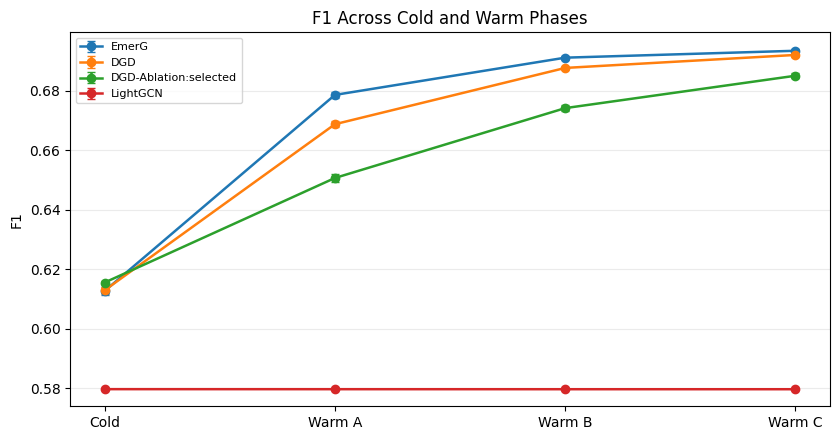

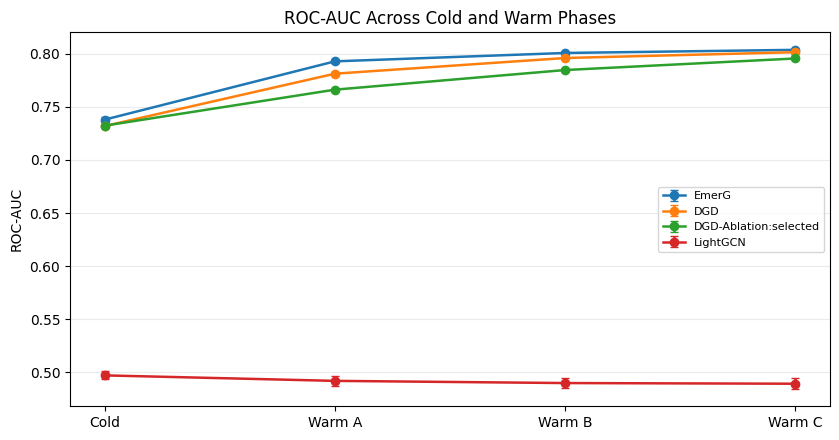

In [2]:
RUN_REGISTRY = TABLES["run_registry"].copy()
PER_RUN_METRICS = TABLES["per_run_metrics"].copy()
AGGREGATE_METRICS = TABLES["aggregate_metrics"].copy()
PHASE_RANKING = TABLES["phase_ranking"].copy()
OVERALL_RANKING = TABLES["overall_ranking"].copy()
SEED_COVERAGE = TABLES["seed_coverage"].copy()
REPRO_AUDIT = TABLES["reproducibility_audit"].copy()
EGD_EMERG_PAIRED = TABLES.get("egd_emerg_paired_deltas", pd.DataFrame())

required_aggregate_columns = {
    "family",
    "model_label",
    "phase",
    "seed_count",
    "f1_mean",
    "f1_std",
    "f1_sem",
    "roc_auc_mean",
    "roc_auc_std",
    "roc_auc_sem",
}
missing_aggregate_columns = required_aggregate_columns - set(AGGREGATE_METRICS.columns)
if missing_aggregate_columns:
    raise RuntimeError(f"Aggregate metrics missing columns: {sorted(missing_aggregate_columns)}")

model_order = OVERALL_RANKING.sort_values("rank")["model_label"].astype(str).tolist()
phase_order = {phase: index for index, phase in enumerate(PHASES)}
model_sort = {model: index for index, model in enumerate(model_order)}


def mean_std_label(row: pd.Series, metric: str) -> str:
    mean = float(row[f"{metric}_mean"])
    std = float(row[f"{metric}_std"]) if pd.notna(row[f"{metric}_std"]) else 0.0
    return f"{mean:.4f} +/- {std:.4f}"


MAIN_COMPARISON = AGGREGATE_METRICS.copy()
MAIN_COMPARISON["phase_order"] = MAIN_COMPARISON["phase"].map(phase_order)
MAIN_COMPARISON["model_order"] = MAIN_COMPARISON["model_label"].map(model_sort)
MAIN_COMPARISON["f1_report"] = MAIN_COMPARISON.apply(mean_std_label, axis=1, metric="f1")
MAIN_COMPARISON["roc_auc_report"] = MAIN_COMPARISON.apply(mean_std_label, axis=1, metric="roc_auc")
MAIN_COMPARISON = MAIN_COMPARISON.sort_values(["model_order", "phase_order"]).reset_index(drop=True)
MAIN_COMPARISON = MAIN_COMPARISON[
    [
        "family",
        "model_label",
        "phase",
        "seed_count",
        "target_seed_count_observed",
        "target_seed_count_met",
        "f1_mean",
        "f1_std",
        "f1_sem",
        "f1_report",
        "roc_auc_mean",
        "roc_auc_std",
        "roc_auc_sem",
        "roc_auc_report",
    ]
]

PHASE_WINNERS = (
    PHASE_RANKING.loc[PHASE_RANKING["rank"].astype(int).eq(1)]
    .copy()
    .sort_values("phase", key=lambda values: values.map(phase_order))
    .reset_index(drop=True)
)
PHASE_WINNERS = PHASE_WINNERS[
    ["phase", "model_label", "seed_count", "f1_mean", "roc_auc_mean"]
]


def metric_figure(metric: str, title: str, ylabel: str) -> plt.Figure:
    mean_column = f"{metric}_mean"
    sem_column = f"{metric}_sem"
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    x = np.arange(len(PHASES), dtype=float)
    for model in model_order:
        rows = AGGREGATE_METRICS[AGGREGATE_METRICS["model_label"].astype(str).eq(model)].copy()
        rows["phase_order"] = rows["phase"].map(phase_order)
        rows = rows.sort_values("phase_order")
        if rows.empty:
            continue
        y = rows[mean_column].astype(float).to_numpy()
        yerr = rows[sem_column].astype(float).fillna(0.0).to_numpy()
        ax.errorbar(x[: len(y)], y, yerr=yerr, marker="o", capsize=3, linewidth=1.8, label=model)
    ax.set_xticks(x)
    ax.set_xticklabels(PHASES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    return fig


FIGURES = {
    "f1_by_phase": metric_figure("f1", "F1 Across Cold and Warm Phases", "F1"),
    "roc_auc_by_phase": metric_figure("roc_auc", "ROC-AUC Across Cold and Warm Phases", "ROC-AUC"),
}
if EGD_EMERG_F1_FIG is not None:
    FIGURES["egd_emerg_f1_delta"] = EGD_EMERG_F1_FIG

display(MAIN_COMPARISON)
display(PHASE_WINNERS)
for figure in FIGURES.values():
    display(figure)

## Paired Deltas, Ablation Selection, and Findings

Keep the analysis concise: paired seed-level deltas compare DGD against each
available model; ablation reporting records which validation-selected variant
was advanced per seed. If upstream coverage or quality warnings exist, they are
carried into the findings instead of hidden.

In [3]:
PAIRED_DELTA_ROWS: list[dict[str, Any]] = []
for metric in ("f1", "roc_auc"):
    for phase in PHASES:
        phase_rows = PER_RUN_METRICS[PER_RUN_METRICS["phase"].astype(str).eq(phase)]
        pivot = phase_rows.pivot(index="seed", columns="model_label", values=metric)
        if "DGD" not in pivot.columns:
            continue
        for model in model_order:
            if model == "DGD" or model not in pivot.columns:
                continue
            paired = pivot[["DGD", model]].dropna()
            if paired.empty:
                continue
            delta = paired["DGD"].astype(float) - paired[model].astype(float)
            PAIRED_DELTA_ROWS.append(
                {
                    "phase": phase,
                    "metric": metric,
                    "comparison": f"DGD - {model}",
                    "seed_count": int(len(delta)),
                    "mean_delta": float(delta.mean()),
                    "std_delta": float(delta.std(ddof=1)) if len(delta) > 1 else np.nan,
                    "min_delta": float(delta.min()),
                    "max_delta": float(delta.max()),
                }
            )
PAIRED_DELTAS = pd.DataFrame(PAIRED_DELTA_ROWS)

ABLATION_SELECTION = RUN_REGISTRY.loc[
    RUN_REGISTRY["family"].astype(str).eq("dgd_ablation"),
    ["seed", "model_label", "selected_variant", "source_status", "bundle_id"],
].copy()
if ABLATION_SELECTION.empty:
    ABLATION_SELECTION = pd.DataFrame(
        columns=["seed", "model_label", "selected_variant", "source_status", "bundle_id"]
    )
selected_variants = sorted(variant for variant in ABLATION_SELECTION["selected_variant"].astype(str).unique() if variant)

# EGD-EmerG paired delta figure
EGD_EMERG_F1_FIG = None
if not EGD_EMERG_PAIRED.empty:
    f1_deltas = EGD_EMERG_PAIRED[EGD_EMERG_PAIRED["metric"].astype(str).eq("f1")]
    if not f1_deltas.empty:
        fig_delta, ax_delta = plt.subplots(figsize=(8.5, 4.5))
        x_delta = np.arange(len(PHASES), dtype=float)
        f1_deltas["phase_order"] = f1_deltas["phase"].map(phase_order)
        f1_deltas = f1_deltas.sort_values("phase_order")
        if not f1_deltas.empty:
            ax_delta.bar(x_delta[: len(f1_deltas)], f1_deltas["mean_delta"].astype(float).to_numpy(), yerr=f1_deltas["std_delta"].astype(float).fillna(0.0).to_numpy(), capsize=5, color="tab:orange", alpha=0.7)
            ax_delta.axhline(0, color="black", linewidth=0.8)
            ax_delta.set_xticks(x_delta[: len(f1_deltas)])
            ax_delta.set_xticklabels(f1_deltas["phase"].astype(str).tolist())
            ax_delta.set_ylabel("EGD - EmerG F1 Delta")
            ax_delta.set_title("EGD vs EmerG — Per-Phase F1 Delta")
            ax_delta.grid(axis="y", alpha=0.25)
            fig_delta.tight_layout()
            EGD_EMERG_F1_FIG = fig_delta
else:
    f1_deltas = pd.DataFrame()

display(EGD_EMERG_F1_FIG)

best_overall = OVERALL_RANKING.sort_values("rank").iloc[0]
cold_winner = PHASE_WINNERS.loc[PHASE_WINNERS["phase"].astype(str).eq("Cold")]
cold_winner_text = (
    str(cold_winner.iloc[0]["model_label"]) if not cold_winner.empty else "unavailable"
)
dgd_rows = AGGREGATE_METRICS[AGGREGATE_METRICS["model_label"].astype(str).eq("DGD")]
if not dgd_rows.empty and {"Cold", "Warm C"} <= set(dgd_rows["phase"].astype(str)):
    dgd_phase = dgd_rows.set_index("phase")
    dgd_warm_gain = float(dgd_phase.loc["Warm C", "f1_mean"] - dgd_phase.loc["Cold", "f1_mean"])
else:
    dgd_warm_gain = np.nan
egd_rows = AGGREGATE_METRICS[AGGREGATE_METRICS["model_label"].astype(str).eq("EGD")]
if not egd_rows.empty and {"Cold", "Warm C"} <= set(egd_rows["phase"].astype(str)):
    egd_phase = egd_rows.set_index("phase")
    egd_warm_gain = float(egd_phase.loc["Warm C", "f1_mean"] - egd_phase.loc["Cold", "f1_mean"])
else:
    egd_warm_gain = np.nan
egd_emerg_delta_info = "unavailable"
if not EGD_EMERG_PAIRED.empty:
    f1_d = EGD_EMERG_PAIRED[EGD_EMERG_PAIRED["metric"].astype(str).eq("f1")]
    if not f1_d.empty:
        overall = f1_d.agg({"mean_delta": "mean", "seed_count": "mean"})
        egd_emerg_delta_info = f"mean F1 delta={float(overall['mean_delta']):.4f}, seeds={int(overall['seed_count'])}"
source_warn_count = int(RUN_REGISTRY["source_status"].astype(str).eq("WARN").sum())
coverage_status = str(MULTISEED_MANIFEST["coverage_status"])

FINDINGS = pd.DataFrame(
    [
        {
            "topic": "Best mean F1",
            "finding": f"{best_overall['model_label']} ranks first by mean F1 across phases.",
            "evidence": f"mean F1={float(best_overall['f1_mean']):.4f}, mean ROC-AUC={float(best_overall['roc_auc_mean']):.4f}",
        },
        {
            "topic": "Cold-start phase",
            "finding": f"{cold_winner_text} is the top Cold-phase model by notebook-07 ranking.",
            "evidence": "See phase_winners.csv and f1_by_phase.png.",
        },
        {
            "topic": "Warm-up effect",
            "finding": "DGD Warm C minus Cold F1 is reported as an observed phase delta, not a causal claim.",
            "evidence": "unavailable" if pd.isna(dgd_warm_gain) else f"DGD Warm C - Cold F1={dgd_warm_gain:.4f}",
        },
        {
            "topic": "Ablation selection",
            "finding": "Validation-selected ablation variants are recorded per seed.",
            "evidence": ", ".join(selected_variants) if selected_variants else "No ablation selection rows found.",
        },
        {
            "topic": "EGD - EmerG paired delta",
            "finding": "Per-seed paired F1 and ROC-AUC deltas between EGD and its EmerG backbone are computed.",
            "evidence": egd_emerg_delta_info,
        },
        {
            "topic": "Warnings and coverage",
            "finding": "Upstream WARN/PARTIAL status is preserved in this report.",
            "evidence": f"coverage={coverage_status}, source WARN runs={source_warn_count}, audit WARN checks={len(REPORT_WARNINGS)}",
        },
    ]
)

FINDINGS_MARKDOWN = "\n".join(
    ["# Results Summary", ""]
    + [f"- **{row.topic}:** {row.finding} Evidence: {row.evidence}" for row in FINDINGS.itertuples(index=False)]
    + [
        "",
        "## Limitations",
        "- Results depend on notebook 02's fixed MovieLens-1M protocol and notebook 07's verified aggregation.",
        "- WARN or PARTIAL upstream status should be reported explicitly instead of treated as a clean final result.",
        "- Notebook 08 formats evidence only; it does not introduce new dataset splits, training, or threshold selection.",
    ]
)

display(PAIRED_DELTAS)
display(ABLATION_SELECTION)
display(FINDINGS)
display(Markdown(FINDINGS_MARKDOWN))

,phase,metric,comparison,seed_count,mean_delta,std_delta,min_delta,max_delta
0,Cold,f1,DGD - EmerG,5,0.000234,0.002838,-0.003085,0.004729
1,Cold,f1,DGD - DGD-Ablation:selected,5,-0.002590,0.002845,-0.006920,0.000197
2,Cold,f1,DGD - LightGCN,5,0.033254,0.002739,0.029092,0.036618
3,Warm A,f1,DGD - EmerG,5,-0.009845,0.002762,-0.013243,-0.006152
4,Warm A,f1,DGD - DGD-Ablation:selected,5,0.018076,0.004536,0.010451,0.022647
5,Warm A,f1,DGD - LightGCN,5,0.089075,0.002387,0.086127,0.091428
6,Warm B,f1,DGD - EmerG,5,-0.003449,0.001969,-0.006431,-0.001984
7,Warm B,f1,DGD - DGD-Ablation:selected,5,0.013507,0.002545,0.009538,0.015994
8,Warm B,f1,DGD - LightGCN,5,0.107996,0.000913,0.107123,0.109255
9,Warm C,f1,DGD - EmerG,5,-0.001400,0.001278,-0.003072,0.000009


,seed,model_label,selected_variant,source_status,bundle_id
5,2025,DGD-Ablation:selected,full_dgd,PASS,20260717T021403351014-s2025-cc8981404b56
6,3407,DGD-Ablation:selected,full_dgd,PASS,20260717T023114264309-s3407-6803fb024589
7,4517,DGD-Ablation:selected,full_dgd,PASS,20260717T023658001768-s4517-5cf69cee9acf
8,7788,DGD-Ablation:selected,full_dgd,PASS,20260717T021946974431-s7788-001c9cfe9c5b
9,9999,DGD-Ablation:selected,full_dgd,PASS,20260717T022529670475-s9999-7c3011e765ac


,topic,finding,evidence
0,Best mean F1,EmerG ranks first by mean F1 across phases.,"mean F1=0.6690, mean ROC-AUC=0.7840"
1,Cold-start phase,DGD-Ablation:selected is the top Cold-phase mo...,See phase_winners.csv and f1_by_phase.png.
2,Warm-up effect,DGD Warm C minus Cold F1 is reported as an obs...,DGD Warm C - Cold F1=0.0791
3,Ablation selection,Validation-selected ablation variants are reco...,full_dgd
4,Warnings and coverage,Upstream WARN/PARTIAL status is preserved in t...,"coverage=COMPLETE, source WARN runs=5, audit W..."


# Results Summary

- **Best mean F1:** EmerG ranks first by mean F1 across phases. Evidence: mean F1=0.6690, mean ROC-AUC=0.7840
- **Cold-start phase:** DGD-Ablation:selected is the top Cold-phase model by notebook-07 ranking. Evidence: See phase_winners.csv and f1_by_phase.png.
- **Warm-up effect:** DGD Warm C minus Cold F1 is reported as an observed phase delta, not a causal claim. Evidence: DGD Warm C - Cold F1=0.0791
- **Ablation selection:** Validation-selected ablation variants are recorded per seed. Evidence: full_dgd
- **Warnings and coverage:** Upstream WARN/PARTIAL status is preserved in this report. Evidence: coverage=COMPLETE, source WARN runs=5, audit WARN checks=1

## Limitations
- Results depend on notebook 02's fixed MovieLens-1M protocol and notebook 07's verified aggregation.
- WARN or PARTIAL upstream status should be reported explicitly instead of treated as a clean final result.
- Notebook 08 formats evidence only; it does not introduce new dataset splits, training, or threshold selection.

## Report Export

Publish a small immutable report bundle for notebook 09 and for the written
report/slides. CSVs keep numeric values, PNGs are reproducible figure outputs,
and `findings.md` provides a concise text summary traceable to notebook 07.

In [4]:
REPORT_CHECKS: list[dict[str, Any]] = []


def report_check(name: str, condition: bool, observed: Any, expected: Any, severity: str = "ERROR") -> None:
    REPORT_CHECKS.append(
        {
            "check": name,
            "status": "PASS" if condition else severity,
            "observed": observed,
            "expected": expected,
            "severity": severity,
        }
    )


report_check("upstream schema", MULTISEED_MANIFEST["evaluation_schema_version"] == "multiseed-evaluation-v1", MULTISEED_MANIFEST["evaluation_schema_version"], "multiseed-evaluation-v1")
report_check("no upstream blocking errors", not REPRO_AUDIT["status"].astype(str).eq("ERROR").any(), REPRO_AUDIT["status"].value_counts().to_dict(), "no ERROR")
report_check("coverage complete", coverage_status == "COMPLETE", coverage_status, "COMPLETE", severity="WARN")
report_check("upstream status clean", MULTISEED_MANIFEST["evaluation_status"] == "PASS", MULTISEED_MANIFEST["evaluation_status"], "PASS", severity="WARN")
report_check("main table nonempty", not MAIN_COMPARISON.empty, len(MAIN_COMPARISON), "> 0")
report_check("figures generated", {"f1_by_phase", "roc_auc_by_phase"} <= set(FIGURES), sorted(FIGURES), "f1_by_phase, roc_auc_by_phase [, egd_emerg_f1_delta]")
report_check("findings generated", not FINDINGS.empty and bool(FINDINGS_MARKDOWN.strip()), len(FINDINGS), "> 0")

REPORT_STATUS = (
    "BLOCKED"
    if any(row["status"] == "ERROR" for row in REPORT_CHECKS)
    else "WARN"
    if any(row["status"] == "WARN" for row in REPORT_CHECKS)
    else "PASS"
)
if REPORT_STATUS == "BLOCKED":
    display(pd.DataFrame(REPORT_CHECKS))
    raise RuntimeError("Notebook 08 report export is blocked by failed checks")


def json_ready(value: Any) -> Any:
    if value is None or isinstance(value, (str, int, bool)):
        return value
    if isinstance(value, float):
        if not np.isfinite(value):
            raise ValueError(f"Non-finite value cannot be serialized to JSON: {value}")
        return value
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_ready(item) for item in value]
    if hasattr(value, "item"):
        return json_ready(value.item())
    return str(value)


def write_text(path: Path, content: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(f".{path.name}.{uuid.uuid4().hex}.tmp")
    temporary.write_text(content, encoding="utf-8")
    temporary.replace(path)


def write_csv(path: Path, table: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(f".{path.name}.{uuid.uuid4().hex}.tmp")
    table.to_csv(temporary, index=False, lineterminator="\n")
    temporary.replace(path)


def relative_output(path: Path) -> str:
    return str(path.resolve().relative_to(ARTIFACT_ROOT.resolve()))


def csv_schema(table: pd.DataFrame) -> dict[str, Any]:
    def dtype_name(dtype: Any) -> str:
        name = str(dtype)
        return "string" if name in {"str", "string"} or name.startswith("string") else name

    return {
        "columns": list(table.columns),
        "read_csv_dtypes": {column: dtype_name(dtype) for column, dtype in table.dtypes.items()},
    }


REPORT_TABLES = {
    "main_comparison": MAIN_COMPARISON,
    "phase_winners": PHASE_WINNERS,
    "paired_deltas_vs_dgd": PAIRED_DELTAS,
    "egd_vs_emerg_paired_deltas": EGD_EMERG_PAIRED,
    "ablation_selection": ABLATION_SELECTION,
    "findings": FINDINGS,
}
bundle_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S") + "-" + uuid.uuid4().hex[:12]
staging_root = OUTPUT_ROOT / f".staging-{bundle_id}"
generation_root = OUTPUT_ROOT / "generations" / bundle_id
pointer_path = OUTPUT_ROOT / "manifest.json"
previous_pointer_text = pointer_path.read_text(encoding="utf-8") if pointer_path.is_file() else None
generation_published = False
pointer_write_attempted = False
staging_root.mkdir(parents=True, exist_ok=False)
OUTPUT_ARTIFACTS: dict[str, Any] = {}
OUTPUT_SCHEMAS: dict[str, Any] = {}

try:
    for name, table in REPORT_TABLES.items():
        staging_path = staging_root / f"{name}.csv"
        published_path = generation_root / f"{name}.csv"
        write_csv(staging_path, table)
        OUTPUT_ARTIFACTS[name] = {
            "path": relative_output(published_path),
            "sha256": sha256_file(staging_path),
            "rows": len(table),
        }
        OUTPUT_SCHEMAS[name] = csv_schema(table)

    for name, figure in FIGURES.items():
        staging_path = staging_root / f"{name}.png"
        published_path = generation_root / f"{name}.png"
        figure.savefig(staging_path, dpi=160, bbox_inches="tight")
        OUTPUT_ARTIFACTS[name] = {
            "path": relative_output(published_path),
            "sha256": sha256_file(staging_path),
        }

    findings_path = staging_root / "findings.md"
    write_text(findings_path, FINDINGS_MARKDOWN + "\n")
    OUTPUT_ARTIFACTS["findings_markdown"] = {
        "path": relative_output(generation_root / "findings.md"),
        "sha256": sha256_file(findings_path),
    }

    manifest = {
        "report_schema_version": "results-report-v1",
        "report_status": REPORT_STATUS,
        "coverage_status": coverage_status,
        "bundle_id": bundle_id,
        "bundle_manifest": relative_output(generation_root / "manifest.json"),
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "upstream_multiseed": {
            "schema_version": MULTISEED_MANIFEST["evaluation_schema_version"],
            "bundle_id": MULTISEED_MANIFEST["bundle_id"],
            "pointer_sha256": MULTISEED_POINTER_SHA256,
            "evaluation_status": MULTISEED_MANIFEST["evaluation_status"],
            "coverage_status": coverage_status,
        },
        "summary": {
            "best_model_by_mean_f1": str(best_overall["model_label"]),
            "best_mean_f1": float(best_overall["f1_mean"]),
            "best_mean_auc": float(best_overall["roc_auc_mean"]),
            "cold_phase_winner": cold_winner_text,
            "source_warn_runs": source_warn_count,
            "target_seed_count": len(TARGET_SEEDS),
        },
        "checks": REPORT_CHECKS,
        "artifacts": OUTPUT_ARTIFACTS,
        "output_schemas": OUTPUT_SCHEMAS,
        "report_contract": {
            "source": "notebook 07 multiseed evaluation bundle",
            "training": "none",
            "dataset": "not reimplemented here; notebook 02 owns MovieLens-1M protocol artifacts",
            "thresholds": "inherited from validation-selected thresholds already verified by notebook 07",
        },
    }

    manifest_text = strict_json_dumps(json_ready(manifest), indent=2, sort_keys=True) + "\n"
    write_text(staging_root / "manifest.json", manifest_text)
    generation_root.parent.mkdir(parents=True, exist_ok=True)
    staging_root.replace(generation_root)
    generation_published = True
    artifact_hashes_match = all(
        sha256_file(resolve_inside(ARTIFACT_ROOT, artifact["path"])) == artifact["sha256"]
        for artifact in OUTPUT_ARTIFACTS.values()
    )
    if not artifact_hashes_match or (generation_root / "manifest.json").read_text(encoding="utf-8") != manifest_text:
        raise RuntimeError("Published report generation failed pre-pointer verification")
    pointer_write_attempted = True
    write_text(pointer_path, manifest_text)
    if pointer_path.read_text(encoding="utf-8") != manifest_text:
        raise RuntimeError("Report pointer does not match the verified generation")
except Exception:
    try:
        if pointer_write_attempted:
            if previous_pointer_text is None:
                pointer_path.unlink(missing_ok=True)
            else:
                write_text(pointer_path, previous_pointer_text)
    finally:
        if staging_root.exists():
            shutil.rmtree(staging_root, ignore_errors=True)
        if generation_published and generation_root.exists():
            shutil.rmtree(generation_root)
    raise

REPORT_MANIFEST = manifest
REPORT_POINTER = pointer_path
show_records(
    [
        {
            "report_status": REPORT_STATUS,
            "coverage_status": coverage_status,
            "bundle_id": bundle_id,
            "manifest": str(pointer_path),
            "artifacts": len(OUTPUT_ARTIFACTS),
        }
    ]
)

,report_status,coverage_status,bundle_id,manifest,artifacts
0,WARN,COMPLETE,20260717T025535-d599074f5fd8,/kaggle/working/artifacts/reports/ml-1m/result...,8


## Final Checks and Continuation

The final cell verifies the report pointer, all artifact hashes, and whether the
result is clean (`READY`) or usable with warnings (`WARN`). Notebook 09 should
consume this report manifest for a compact demo, and should go back to notebook
02 only if it needs to show protocol rows interactively.

In [5]:
FINAL_CHECKS: list[dict[str, Any]] = list(REPORT_CHECKS)


def final_check(name: str, condition: bool, observed: Any, expected: Any) -> None:
    FINAL_CHECKS.append(
        {
            "check": name,
            "status": "PASS" if condition else "ERROR",
            "observed": observed,
            "expected": expected,
            "severity": "ERROR",
        }
    )


pointer_matches_bundle = REPORT_POINTER.read_text(encoding="utf-8") == (generation_root / "manifest.json").read_text(encoding="utf-8")
all_hashes_verify = all(
    sha256_file(resolve_inside(ARTIFACT_ROOT, artifact["path"])) == artifact["sha256"]
    for artifact in REPORT_MANIFEST["artifacts"].values()
)
final_check("manifest pointer matches report bundle", pointer_matches_bundle, pointer_matches_bundle, True)
final_check("report artifact hashes verify", all_hashes_verify, all_hashes_verify, True)
final_check("main comparison exported", "main_comparison" in REPORT_MANIFEST["artifacts"], True, True)
final_check("figures exported", {"f1_by_phase", "roc_auc_by_phase"} <= set(REPORT_MANIFEST["artifacts"]), sorted(REPORT_MANIFEST["artifacts"]), "required figures")

FINAL_AUDIT = pd.DataFrame(FINAL_CHECKS)
FINAL_BLOCKED = FINAL_AUDIT["status"].eq("ERROR").any()
NOTEBOOK_STATUS = "BLOCKED" if FINAL_BLOCKED else "WARN" if REPORT_STATUS == "WARN" else "READY"
display(FINAL_AUDIT)
display(Markdown("### Notebook 08 results and figures: " + NOTEBOOK_STATUS))

if FINAL_BLOCKED:
    raise RuntimeError("Notebook 08 final report checks failed")

display(
    Markdown(
        "**Next notebook:** notebook 09 should read `reports/ml-1m/results-v1/manifest.json` "
        "for report tables/figures, and optionally read notebook-02 protocol artifacts only for a small live demo."
    )
)

,check,status,observed,expected,severity
0,upstream schema,PASS,multiseed-evaluation-v1,multiseed-evaluation-v1,ERROR
1,no upstream blocking errors,PASS,"{'PASS': 12, 'WARN': 1}",no ERROR,ERROR
2,coverage complete,PASS,COMPLETE,COMPLETE,WARN
3,upstream status clean,WARN,WARN,PASS,WARN
4,main table nonempty,PASS,16,> 0,ERROR
5,figures generated,PASS,"[f1_by_phase, roc_auc_by_phase]","[f1_by_phase, roc_auc_by_phase]",ERROR
6,findings generated,PASS,5,> 0,ERROR
7,manifest pointer matches report bundle,PASS,True,True,ERROR
8,report artifact hashes verify,PASS,True,True,ERROR
9,main comparison exported,PASS,True,True,ERROR


### Notebook 08 results and figures: WARN

**Next notebook:** notebook 09 should read `reports/ml-1m/results-v1/manifest.json` for report tables/figures, and optionally read notebook-02 protocol artifacts only for a small live demo.